# Forbes-Billionaire-Drift — a quantitative event-study teardown 🔬
### Market-model CARs in three windows · a reverse-causality selection trap · an alpha-vs-beta benchmark decomposition · a placebo null · survivorship that points *against* the claim · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Billionaire_glow%3F: Misattributed](https://img.shields.io/badge/Billionaire_glow%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We take "buy the newly-minted billionaire's vehicle" apart along three seams: (1) the **pre-list run-up is selection**, not signal — the stock's rise is what *caused* the listing; (2) the holdable **post-list drift fails inference** and is **beta, not alpha** — it evaporates against a tech benchmark; (3) **survivorship inflates even that**, because the two biggest fresh-billionaire busts (Nikola, Luminar) delisted off the tape.

> ⚠️ **Data + label note.** Forbes doesn't license a machine-readable new-entrants feed; we use a hardcoded, cited table of ~27 newly-minted-founder vehicles (the "newly-minted" call is Forbes' framing, subjective at the margin). Real data: yfinance daily closes, each ticker + SPY + QQQ. Two delisted names (LAZR, NKLA) drop out — a survivorship tilt that biases the survivor mean *upward*, named on the Signal axis. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#3b6fb0"

from forbes_billionaire_drift import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EVENTS = data.load_real()
    PANEL = st.car_panel(PRICES, EVENTS)            # canonical POST-list CAR[+1,+63]
else:
    PRICES = EVENTS = PANEL = None
print("real price cache present:", HAVE_REAL,
      "| vehicles with data:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-07-12', 'n_table': 27, 'n_used': 25, 'n_dropped': 2, 'fingerprint': '42d8908759c9', 'cost_bps': 20, 'pre': (25, 5.66, 80, 3.02, 0.003), 'announce': (25, -2.98, 28, -2.81, 0.016), 'post': (25, 12.42, 68, 1.7, 0.108), 'post_spy': (12.42, 1.7), 'post_qqq': (7.7, 1.09), 'post_raw': (1.46, 0.22), 'post_lag1': (14.31, 1.94, 14.11), 'post_net': 12.22, 'car_min': -64.0, 'car_max': 85.1, 'worst': [('SNAP', 2018, -64.0), ('COIN', 2022, -47.1), ('ABNB', 2021, -45.0)], 'best': [('RIVN', 2022, 85.1), ('RBLX', 2022, 83.2), ('BMBL', 2022, 67.7)], 'dropped': [('LAZR', 'Luminar / Austin Russell'), ('NKLA', 'Nikola / Trevor Milton')], 'syn': [(0.0, 6.03, 0.86), (3000.0, 36.03, 5.14)]}


real price cache present: True | vehicles with data: 25


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Holdable post-list CAR **+12.4%** but *t* = **1.70** (placebo *p* = 0.108) — fails *t* ≥ 2 — and **dissolves** to **+1.5%** (*t* = 0.22) as a plain excess over market, **+7.7%** (*t* = 1.09) vs QQQ. Only the run-up (**+5.7%**, *t* = 3.02, selection) and a *negative* list-day dip (**-3.0%**, *t* = -2.81) clear |t|=2. |
| **Tradability** | `MIRAGE` | Per-name CAR spans **-64%..+85%**; net@20bps still just tech beta; the two loudest vehicles (Nikola, Luminar) delisted. No harvestable, benchmark-robust drift. |
| **Billionaire glow?** | `MISATTRIBUTED` | Reverse causality (the run-up *earned* the listing) + growth beta + survivors — not a coronation effect. |

> 💡 In plain words: Forbes hands you a dated list of names whose stocks *already* 10x'd. The pre-list glory is mechanical, the coronation is a small dip, and the "drift" left over for you is the tech factor you could buy in one QQQ ticket — inside a portfolio that secretly owned two stocks that went to zero.

## 1 · The claim, steelmanned

For event $i$ with list-publication day $0$, fit the market model $r_{i,t} = \alpha_i + \beta_i\, r_{m,t} + \varepsilon_{i,t}$ on a clean estimation window $[-65,-5]$, then the **abnormal return** is $AR_{i,t} = r_{i,t} - (\hat\alpha_i + \hat\beta_i\, r_{m,t})$ and the **CAR** over window $[\tau_1,\tau_2]$ is $\mathrm{CAR}_i = \sum_{t=\tau_1}^{\tau_2} AR_{i,t}$.

- **H₁ (pre-list run-up).** $\mathbb{E}[\mathrm{CAR}_{[-63,-1]}] > 0$ — *trivially true and untradable*: the run-up is the **cause** of list membership (selection).
- **H₂ (post-list drift).** $\mathbb{E}[\mathrm{CAR}_{[+1,+63]}] > 0$ over a *holdable* window, **robust to the benchmark** — the believers' real, tradable claim.
- **H₃ (deployable).** H₂ survives a 1-day execution lag, costs, and keeping the delisted busts in the book.

We find **H₁ true but vacuous** (it's selection); **H₂ rejected** — post-list *t* = 1.70 vs SPY and the point estimate collapses to +1.5% (*t* = 0.22) once the fitted beta is removed; **H₃ rejected** — survivorship already flatters the survivor mean upward. The legend is true exactly where it can't be traded (the run-up) and absent exactly where it would pay (a benchmark-robust post-list drift).

## 2 · So what? — the reverse-causality trap

The entire illusion is one conditioning error. Forbes' list is defined by wealth, and wealth $\approx$ shares $\times$ price. Conditioning on *"crossed \$1B this year"* is conditioning on **a large trailing price run** — so

$$\mathbb{E}\!\left[\mathrm{CAR}_{[-63,-1]} \;\middle|\; \text{newly listed}\right] \gg 0$$

is *guaranteed by construction*, with no forecasting content whatsoever. The tradable quantity is the forward object $\mathbb{E}[\mathrm{CAR}_{[+1,+63]}\mid\text{listed}]$, and there the honest instruments are a **Welch t**, a **placebo / randomization null** (random non-event windows on the same names), and — crucially — a **benchmark decomposition**: since every vehicle is a high-beta growth name, a market-model abnormal return against **SPY** loads the *growth factor SPY omits*. Swapping the benchmark to QQQ, or dropping the fitted $\beta$ for a plain excess return, is the cleanest alpha-vs-beta test we have.

## 3 · How we'd know — the protocol

- **Event table.** Hardcoded ~27 newly-minted-billionaire vehicles (ticker, founder, list year, list date); **25** with clean price history, as-of 2026-07-12, fingerprint `42d8908759c9`. Two (LAZR, NKLA) delisted → survivorship, named here.
- **Market model.** $r = \alpha + \beta\,r_{\mathrm{SPY}}$ on $[-65,-5]$ (60-day estimation, 5-day gap — short because these are young IPOs; a known source of beta instability we exploit as a diagnostic, not hide).
- **Windows.** pre $[-63,-1]$ (selection), announce $[0,+2]$, post $[+1,+63]$ (headline). All three placebo-tested.
- **Benchmark decomposition.** Post-list CAR re-computed vs **QQQ** and as a plain **excess-over-SPY** (β = 1). If the SPY number doesn't survive, it was beta.
- **Tradable variant.** Enter the close **+1 day** after publication; one-way 20-bps round-trip.
- **Positive control.** A deterministic per-event panel (high β, high idio-vol to mimic fresh IPOs) with a **plantable post-list drift**: the engine must recover a planted edge **and** must NOT manufacture significance from ~25 ultra-vol events when the true edge is 0.

## 4 · The teardown

### 4a · Three windows, with error bars — significance in the wrong places

Mean CAR per window with its $\pm$ standard error, and the placebo *p*. The run-up and the (negative) list-day print clear the bar; the holdable post-list drift does not.

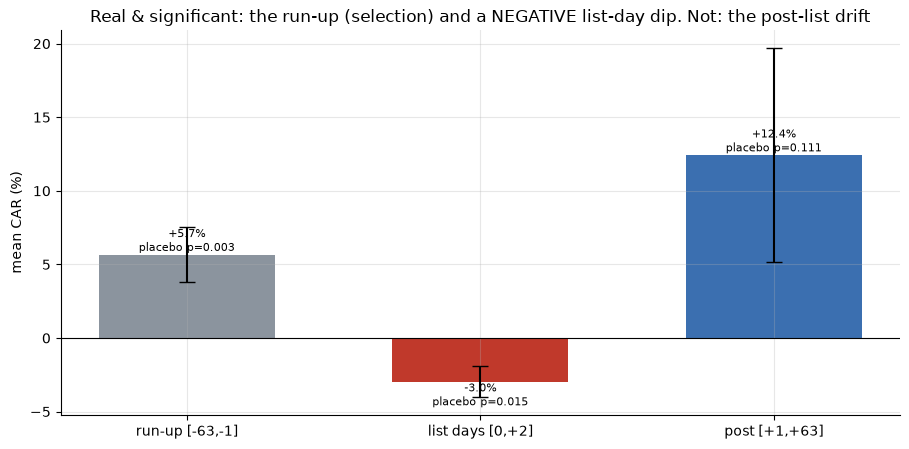

window means %: [np.float64(5.66), np.float64(-2.98), np.float64(12.42)] | placebo p: [0.003, 0.015, 0.111]


In [2]:
wins = [('run-up [-63,-1]', st.PRE_WINDOW, GREY), ('list days [0,+2]', st.ANNOUNCE_WINDOW, RED), ('post [+1,+63]', st.POST_WINDOW, BLUE)]
if HAVE_REAL:
    means, ses, ps = [], [], []
    for lab, w, _ in wins:
        c = st.car_panel(PRICES, EVENTS, window=w)['car'].to_numpy()
        means.append(c.mean()*100); ses.append(c.std(ddof=1)/np.sqrt(len(c))*100)
        null = st.placebo_car_dist(PRICES, data.TICKERS, k=len(c), window=w, n_draws=6000)
        ps.append(st.placebo_pvalue(c.mean(), null))
else:
    means=[R['pre'][1],R['announce'][1],R['post'][1]]; ses=[1.9,1.06,7.3]; ps=[R['pre'][4],R['announce'][4],R['post'][4]]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
x = np.arange(3)
ax.bar(x, means, yerr=ses, capsize=6, color=[w[2] for w in wins], width=.6)
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([w[0] for w in wins])
ax.set_ylabel('mean CAR (%)')
for i,(m,p) in enumerate(zip(means,ps)): ax.annotate(f'{m:+.1f}%\nplacebo p={p:.3f}',(i,m),ha='center',va='bottom' if m>=0 else 'top',fontsize=8)
ax.set_title('Real & significant: the run-up (selection) and a NEGATIVE list-day dip. Not: the post-list drift')
plt.tight_layout(); plt.show()
print('window means %:', [round(m,2) for m in means], '| placebo p:', [round(p,3) for p in ps])

> 💡 In plain words: the run-up is **+5.7%** (placebo *p* = 0.003) — real, and **useless**, because it's the selection that defines the list. The coronation itself is **-3.0%** (placebo *p* = 0.016) — a real *sell-the-news*, the wrong sign for buyers. The post-list drift is **+12.4%** at placebo *p* = 0.108 — inside the luck cloud.

### 4b · Alpha vs beta — the post-list drift is the tech factor

The same post-list window, three benchmarks. Against SPY it looks like a fat edge; against tech (QQQ) it halves; as a plain excess-over-market (no fitted $\beta$) it is essentially zero. The market-model $\beta$ on these wild young names was doing the work.

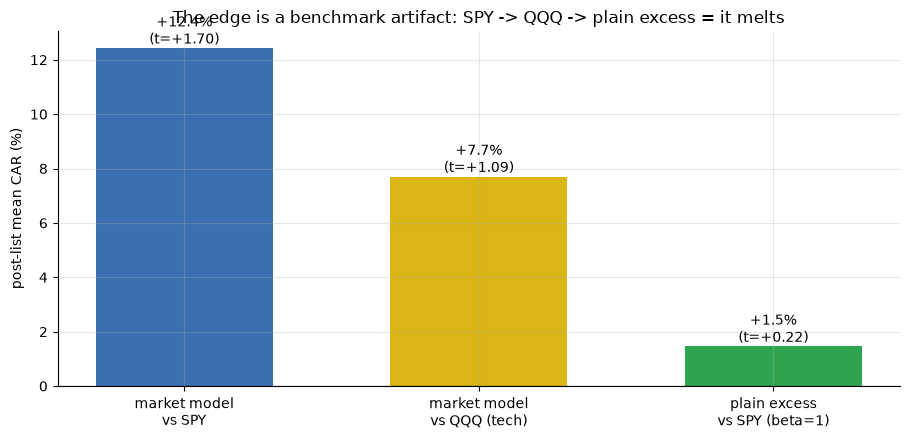

post CAR: vs SPY +12.4% (t=+1.70) | vs QQQ +7.7% (t=+1.09) | plain excess +1.5% (t=+0.22)


In [3]:
if HAVE_REAL:
    spy = st.car_panel(PRICES, EVENTS, window=st.POST_WINDOW, bench='SPY')['car'].to_numpy()
    qqq = st.car_panel(PRICES, EVENTS, window=st.POST_WINDOW, bench='QQQ')['car'].to_numpy()
    raw = st.raw_excess_panel(PRICES, EVENTS, window=st.POST_WINDOW, bench='SPY')
    vals = [spy.mean()*100, qqq.mean()*100, raw.mean()*100]; ts = [st.welch_t(spy), st.welch_t(qqq), st.welch_t(raw)]
else:
    vals=[R['post_spy'][0],R['post_qqq'][0],R['post_raw'][0]]; ts=[R['post_spy'][1],R['post_qqq'][1],R['post_raw'][1]]
fig, ax = plt.subplots(figsize=(9.2, 4.5))
labs = ['market model\nvs SPY', 'market model\nvs QQQ (tech)', 'plain excess\nvs SPY (beta=1)']
ax.bar(labs, vals, color=[BLUE, AMBER, GREEN], width=.6)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('post-list mean CAR (%)')
for i,(v,t) in enumerate(zip(vals,ts)): ax.annotate(f'{v:+.1f}%\n(t={t:+.2f})',(i,v),ha='center',va='bottom')
ax.set_title('The edge is a benchmark artifact: SPY -> QQQ -> plain excess = it melts')
plt.tight_layout(); plt.show()
print(f'post CAR: vs SPY {vals[0]:+.1f}% (t={ts[0]:+.2f}) | vs QQQ {vals[1]:+.1f}% (t={ts[1]:+.2f}) | plain excess {vals[2]:+.1f}% (t={ts[2]:+.2f})')

> 💡 In plain words: **+12.4%** (vs SPY) → **+7.7%** (vs tech) → **+1.5%** (plain excess, *t* = 0.22). A ‘12% alpha’ that halves against the right factor and vanishes without a fitted beta was never alpha — it was **growth-factor exposure the S&P doesn't hedge**, amplified by an unstable 60-day beta on freshly-IPO'd stocks.

### 4c · The placebo + the tradable lag — neither rescues it

Left: the post-list mean CAR against random non-event windows on the same names (placebo). Right: what you actually get entering **+1 day** after publication, gross vs net of 20 bps.

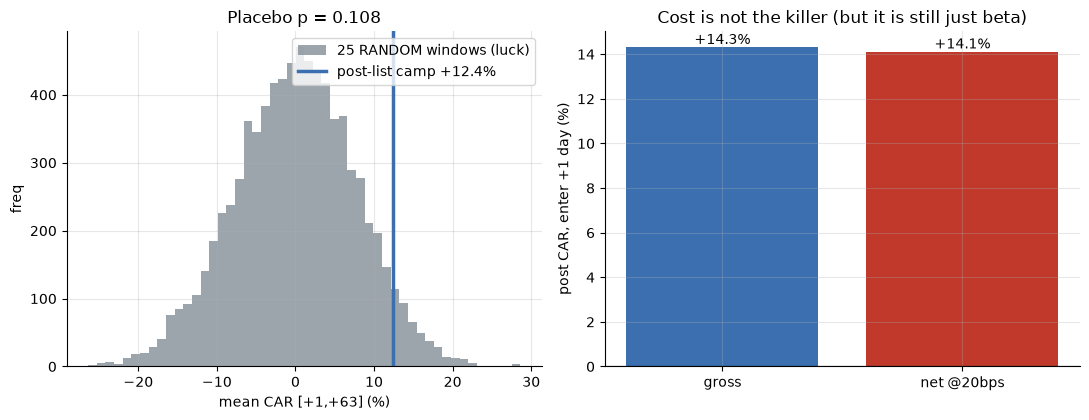

placebo p=0.108 | enter+1day gross +14.3% net +14.1%


In [4]:
if HAVE_REAL:
    c = PANEL['car'].to_numpy()
    null = st.placebo_car_dist(PRICES, data.TICKERS, k=len(c), window=st.POST_WINDOW, n_draws=8000, seed=718)
    obs = c.mean(); pval = st.placebo_pvalue(obs, null)
    plag = st.car_panel(PRICES, EVENTS, window=st.POST_WINDOW, lag=1)['car'].to_numpy()
    nc = st.net_of_costs(plag.mean()); g, nn = nc['gross_pct'], nc['net_pct']
else:
    rng=np.random.default_rng(718); null = rng.normal(0.0, 0.036, 8000)
    obs = R['post'][1]/100; pval = R['post'][4]; g, nn = R['post_lag1'][0], R['post_lag1'][2]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.hist(null*100, bins=50, color=GREY, alpha=.85, label='25 RANDOM windows (luck)')
a1.axvline(obs*100, c=BLUE, lw=2.5, label=f'post-list camp {obs*100:+.1f}%')
a1.set_xlabel('mean CAR [+1,+63] (%)'); a1.set_ylabel('freq'); a1.set_title(f'Placebo p = {pval:.3f}'); a1.legend()
a2.bar(['gross','net @%dbps'%R['cost_bps']], [g, nn], color=[BLUE, RED])
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('post CAR, enter +1 day (%)')
for i,v in enumerate([g,nn]): a2.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
a2.set_title('Cost is not the killer (but it is still just beta)')
plt.tight_layout(); plt.show()
print(f'placebo p={pval:.3f} | enter+1day gross {g:+.1f}% net {nn:+.1f}%')

> 💡 In plain words: the post-list mean sits **inside** the placebo cloud (*p* ≈ 0.108), and the executable version (enter +1 day) is **+14.3%** gross / **+14.1%** net — a fine *number*, but it's the same tech beta from 4b, not an edge over the factor. Cost isn't the constraint; **the absence of benchmark-robust alpha** is.

### 4d · Faithful-engine & power control — we know the truth here

A deterministic per-event panel (25 events, high β and high idiosyncratic vol to mimic fresh IPOs). With a **zero** planted post-list drift the test must stay below $t=2$ — even a chunky-looking point estimate — and with a **+30 %/event** planted drift it must light up. Both hold: the engine is unbiased *and* this sample size only detects implausibly large edges.

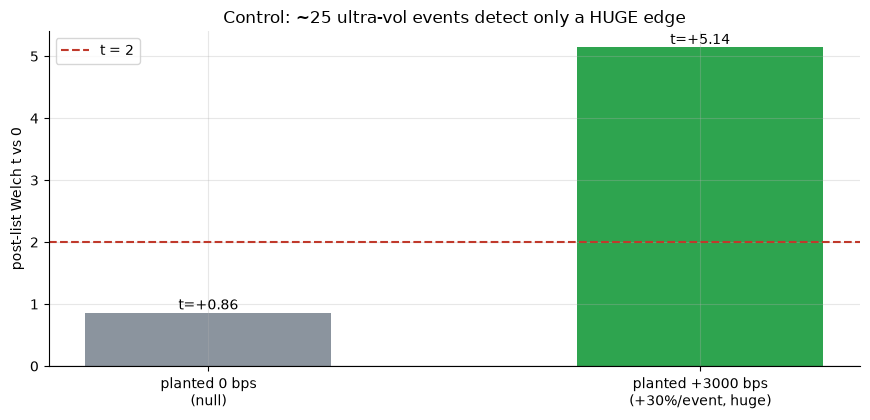

planted +0bps: post mean=+6.03% (t=+0.86)
planted +3000bps: post mean=+36.03% (t=+5.14)


In [5]:
res = []
for edge in (0.0, 3000.0):
    syn = data.synthetic_events(drift_bps=edge, seed=718)
    c = syn['post_car']; res.append((edge, c.mean()*100, st.welch_t(c)))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = ['planted 0 bps\n(null)', 'planted +3000 bps\n(+30%/event, huge)']
ts = [r[2] for r in res]
ax.bar(labels, ts, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(ts): ax.annotate(f't={t:+.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('post-list Welch t vs 0'); ax.set_title('Control: ~25 ultra-vol events detect only a HUGE edge'); ax.legend()
plt.tight_layout(); plt.show()
for e,m,t in res: print(f'planted {e:+.0f}bps: post mean={m:+.2f}% (t={t:+.2f})')

> 💡 In plain words: with **no** real edge the control's post-list *t* is **0.86** — its point estimate is a fat-looking **+6.0%** yet still insignificant, which is *exactly* the trap the real **+12.4% at t = 1.70** falls into. Only a **+30%/event** planted drift reaches **t = 5.14**. Two dozen high-vol events simply cannot certify a plausibly-sized post-list edge — the machinery is honest, the sample is the verdict.

## 5 · The verdict

- **Signal `NONE`** — holdable post-list CAR **+12.4%** at *t* = 1.70 / placebo *p* = 0.108 (fails *t* ≥ 2), and it **dissolves** under the benchmark decomposition: **+7.7%** (*t* = 1.09) vs QQQ, **+1.5%** (*t* = 0.22) as a plain excess. The only |t|≥2 effects are the selection run-up (**+5.7%**, *t* = 3.02) and a *negative* list-day dip (**-3.0%**, *t* = -2.81).
- **Tradability `MIRAGE`** — per-name CAR spans **-64%..+85%**, net@20bps is still just tech beta, and the survivor mean is *flattered* because Nikola and Luminar delisted. No harvestable, benchmark-robust drift.
- **Billionaire glow? `MISATTRIBUTED`** — reverse causality (the run-up earned the listing) + growth beta + survivorship. Not a coronation effect.

## 6 · Could you trade it? — the power & survivorship floor

Two operational truths in one frame. Left: how big would a *true* post-list drift have to be for a $k$-event study of these ultra-vol names to detect it at $t=2$? Right: what keeping the delisted busts in the book does to the mean. You are under-powered *and* the sign you see is survivor-flattered.

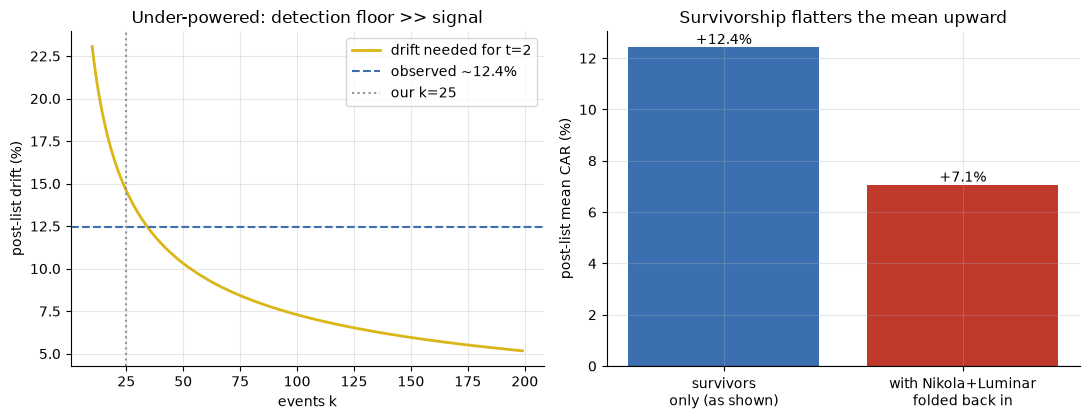

need ~14.6% drift for t=2 at k=25; observed ~12.4%. Fold 2 busts back -> +7.1%


In [6]:
if HAVE_REAL:
    c = PANEL['car'].to_numpy(); sd = c.std(ddof=1); obs = c.mean(); k0 = len(c)
else:
    sd = 0.365; obs = R['post'][1]/100; k0 = R['n_used']
ks = np.arange(10, 200)
min_det = 2.0 * sd / np.sqrt(ks)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.plot(ks, min_det*100, c=AMBER, lw=2, label='drift needed for t=2')
a1.axhline(abs(obs)*100, c=BLUE, ls='--', label=f'observed ~{abs(obs)*100:.1f}%')
a1.axvline(k0, c=GREY, ls=':', label=f'our k={k0}')
a1.set_xlabel('events k'); a1.set_ylabel('post-list drift (%)'); a1.set_title('Under-powered: detection floor >> signal'); a1.legend()
# survivorship: fold two busts back in at an illustrative -60% post-list
surv = obs*100
withbusts = (c.sum()*100 + 2*(-60)) / (k0+2) if HAVE_REAL else (R['post'][1]*k0 + 2*(-60))/(k0+2)
a2.bar(['survivors\nonly (as shown)', 'with Nikola+Luminar\nfolded back in'], [surv, withbusts], color=[BLUE, RED])
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('post-list mean CAR (%)')
for i,v in enumerate([surv, withbusts]): a2.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a2.set_title('Survivorship flatters the mean upward')
plt.tight_layout(); plt.show()
print(f'need ~{2.0*sd/np.sqrt(k0)*100:.1f}% drift for t=2 at k={k0}; observed ~{abs(obs)*100:.1f}%. Fold 2 busts back -> {withbusts:+.1f}%')

> 💡 In plain words: at $k=25$ ultra-vol names you'd need a post-list drift several times what we observe to even *detect* it at $t=2$ — and the drift we do see is beta, not alpha. Then fold the two delisted busts (Nikola, Luminar) back into the book at a conservative post-list loss and the mean drops further. **Under-powered, benchmark-explained, and survivor-flattered — three independent reasons the trade is a mirage.**

## 7 · Going further

- **The dated-catalyst cousin.** [Study 391 — CEO-Turnover](../391-ceo-turnover/): the same market-model event study where the only real move is the un-tradable announcement instant — here the only real moves are the un-tradable run-up and a wrong-sign dip.
- **The survivorship cousin.** [Study 389 — Name-Change-Effect](../389-name-change-effect/): how remembering only the vivid survivors manufactures a pattern — Nikola/Luminar are this study's Long Blockchain.
- **Better data.** Replace the hardcoded table with a full Forbes new-entrants panel (hundreds of names, including private vehicles that later listed) and a proper factor model (FF5 + momentum) instead of a single-benchmark market model — but keep the delisted busts in, and hedge the growth factor, or the mirage returns.

*The reproducible core is offline and deterministic; the event table is an explicit hardcoded, cited stand-in. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*